# Dataset
Dataset: [Social Media Addiction & Mental Wellbeing](https://www.kaggle.com/datasets/harpartapsingh13/social-media-addiction-and-mental-wellbeing-dataset/data)

# Dashboard Visualization
Tableau Public: [Milestone 2 - Rolando Krisnanto](https://public.tableau.com/app/profile/rolando.krisnanto5616/viz/M2_P1_Dashboard_RolandoKrisnanto/Dashboard1?publish=yes)

# Perkenalan

```
Milestone 2

Nama  : Rolando Krisnanto
Batch : CODA-RMT-021

Program ini dibuat untuk kebutuhan Cleansing, Anailisa Data, dan Visualisasi data menggunakan beberapa library di phyton terhadap dataset Social Media Addiction & Mental Wellbeing
```

# Idenfitikasi Masalah

Latar Belakang:
> Media sosial sudah menjadi bagian dari kehidupan sehari-hari. Media Sosial biasanya digunakan untuk berkomunikasi, mencari hiburan, serta mendapatkan informasi. Namun, penggunaan media sosial yang berlebihan dapat mengakibatkan berbagai macam masalah, diantaranya seperti kecanduan, kecemasan, gangguan tidur, dan masih banyak lagi.

> Oleh karena itu, analisis ini dilakukan untuk melihat hubungan antara faktor-faktor pada perilaku penggunaan media sosial dan kondisi kesehatan mental dengan tingkat kecanduan media sosial serta kesejahteraan mental pengguna. Lebih dari 1.000 data pengguna digunakan untuk mengetahui faktor-faktor yang memiliki hubungan dengan kedua aspek tersebut.

Dataset: [Social Media Addiction & Mental Wellbeing](https://www.kaggle.com/datasets/harpartapsingh13/social-media-addiction-and-mental-wellbeing-dataset/data)

Problem Statement:
- Menganalisis hubungan antara faktor-faktor pada Kesehatan Mental dan Perilaku Penggunaan Media Sosial dengan Skor Kesejahteraan Mental dan Tingkat Kecanduan Sosial Media pada sekitar 1000 pengguna lebih, guna melihat faktor-faktor Kesehatan Mental dan Perilaku Penggunaan Sosial Media yang berpengaruh terhadap Tingkat Kecanduan Penggunaan Sosial Media, dan diselesaikan dalam 4 hari.

SMART:
- Specific: Platform Behavior, Mental Health Indicators, dan Addiction Level
- Measureable: Demographic Profile (user_id, age, gender), Platform Behavior (primary_platform, daily_usage_hours), Mental Health Indicators (anxiety_score, depression_score, loneliness_score, sleep_quality_score, sleep_hours), Mental Wellbeing Score, dan Addiction Level
- Achievable: 1000 data lebih pengguna sosial media
- Relevant: Faktor-faktor yang berpengaruh terhadap Kesehatan Mental dan Tingkat Kecanduan Penggunaan Sosial Media
- Time Bound: 4 Hari

Key Problem:
1. Pada kelompok Umur (age) dan Gender (gender) apa yang memiliki Tingkat Kecanduan Tertinggi (addiction_level)?
2. Pada Platform Media Sosial (primary_platform) apa yang memiliki Tingkat Kecanduan (addiction_level) tertinggi?
3. Apakah semakin lama Durasi Penggunaan Media Sosial (daily_usage_hours) semakin tinggi juga Tingkat Kecanduannya (addiction_level)?
4. Apakah Anxiety (anxiety_score) dan Depresi (depression_score) berhubungan dengan Skor Kesejahteraan Mental (mental_wellbeing_score)?
5. Apakah Kualitas Tidur (sleep_quality_score) dan Durasi Tidur (sleep_hours) berhubungan dengan Skor Kesejahteraan Mental (mental_wellbeing_score)?
6. Apakah orang yang Kesepian (loneliness_score) memiliki Skor Kesejahteraan Mental (mental_wellbeing_score) yang kecil?
7. Bagaimana hubungan antara Addiction_Level itu sendiri dengan Mental_Wellbeing_Score?

# Data Loading

```
1. CREATE DATABASE:
CREATE DATABASE coda_21_m2;

2. CREATE TABLE STAGING:
CREATE TABLE social_media_staging (
    user_id VARCHAR(50),
    age INTEGER,
    gender VARCHAR(50),
    occupation VARCHAR(50),
    relationship_status VARCHAR(50),
    -- platform behavior
    primary_platform VARCHAR(50),
    daily_usage_hours FLOAT,
    platforms_used_count INTEGER,
    posts_per_week INTEGER,
    late_night_usage VARCHAR(50),
    first_check_morning VARCHAR(50),
    notifications_per_day INTEGER,
    -- psychological patterns
    fomo_score FLOAT,
    social_comparison_score FLOAT,
    validation_seeking_score FLOAT,
    scroll_without_purpose FLOAT,
    tried_to_cut_back VARCHAR(50),
    failed_to_cut_back VARCHAR(50),
    -- mental health indicators
    anxiety_score FLOAT,
    depression_score FLOAT,
    loneliness_score FLOAT,
    self_esteem_score FLOAT,
    sleep_quality_score FLOAT,
    sleep_hours FLOAT,
    -- lifestyle balance
    productivity_loss_score FLOAT,
    offline_relationship_quality FLOAT,
    physical_activity_hrs_week FLOAT,
    screen_free_time_hrs FLOAT,
    -- targets
    mental_wellbeing_score FLOAT,
    addiction_level VARCHAR(50)
);

3. INSERT DATA KE TABEL STAGING FROM CSV:
COPY social_media_staging
FROM 'C:\TEMP\social_media_addiction_mental_wellbeing_raw.csv'
DELIMITER ','
CSV HEADER
;

4. TABLE YANG AKAN DIGUNAKAN:
SELECT
    user_id,
    age,
    gender,
    -- platform behavior
    primary_platform,
    daily_usage_hours,
    -- mental health indicators
    anxiety_score,
    depression_score,
    loneliness_score,
    sleep_quality_score,
    sleep_hours,
    -- targets
    mental_wellbeing_score,
    addiction_level
FROM social_media_staging;

5. INSERT DATA DARI TABEL STAGING KE TABEL FINAL (social_media_addiction_mental_wellbeing):
INSERT INTO social_media_addiction_mental_wellbeing SELECT
    user_id,
    age,
    gender,
    primary_platform,
    daily_usage_hours,
    anxiety_score,
    depression_score,
    loneliness_score,
    sleep_quality_score,
    sleep_hours,
    mental_wellbeing_score,
    addiction_level
FROM social_media_staging;

```

# Data Cleaning

## Import Library

In [248]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

## Import raw data

In [249]:
# Import raw .csv data
data = pd.read_csv('social_media_addiction_mental_wellbeing_raw.csv', delimiter= ',')

data.head(5)

,User_ID,Age,Gender,Occupation,Relationship_Status,Primary_Platform,Daily_Usage_Hours,Platforms_Used_Count,Posts_Per_Week,Late_Night_Usage,...,Loneliness_Score,Self_Esteem_Score,Sleep_Quality_Score,Sleep_Hours,Productivity_Loss_Score,Offline_Relationship_Quality,Physical_Activity_Hrs_Week,Screen_Free_Time_Hrs,Mental_Wellbeing_Score,Addiction_Level
0,USR00001,30,Male,Working Professional,In a Relationship,YouTube,2.9,4,3,No,...,1.7,6.5,8.5,5.3,3.7,3.8,5.8,3.1,7.3,Low
1,USR00002,19,Male,Student,Married,Instagram,4.8,1,0,NaN,...,7.0,7.5,7.8,5.5,4.0,1.8,0.9,3.3,4.1,Severe
2,USR00003,40,Male,Student,In a Relationship,YouTube,NaN,4,5,No,...,5.6,5.3,6.3,NaN,5.8,2.8,0.0,1.5,5.6,High
3,USR00004,37,Female,Student,Married,Facebook,7.7,2,3,Yes,...,5.6,1.4,3.9,6.1,5.5,3.6,1.0,3.9,4.3,Severe
4,USR00005,18,Non-binary,Student,In a Relationship,TikTok,4.6,3,0,No,...,4.0,NaN,5.7,5.0,3.8,3.2,0.6,1.0,6.6,Moderate


## Cek Struktur Data

In [250]:
# Cek struktur data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 30 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   User_ID                       1500 non-null   object 
 1   Age                           1500 non-null   int64  
 2   Gender                        1447 non-null   object 
 3   Occupation                    1455 non-null   object 
 4   Relationship_Status           1449 non-null   object 
 5   Primary_Platform              1447 non-null   object 
 6   Daily_Usage_Hours             1444 non-null   float64
 7   Platforms_Used_Count          1500 non-null   int64  
 8   Posts_Per_Week                1500 non-null   int64  
 9   Late_Night_Usage              1450 non-null   object 
 10  First_Check_Morning           1500 non-null   object 
 11  Notifications_Per_Day         1500 non-null   int64  
 12  FOMO_Score                    1445 non-null   float64
 13  Soc

In [251]:
# Ubah semua nama kolom menjadi lowercase untuk mempermudah
data.columns = data.columns.str.lower()

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 30 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   user_id                       1500 non-null   object 
 1   age                           1500 non-null   int64  
 2   gender                        1447 non-null   object 
 3   occupation                    1455 non-null   object 
 4   relationship_status           1449 non-null   object 
 5   primary_platform              1447 non-null   object 
 6   daily_usage_hours             1444 non-null   float64
 7   platforms_used_count          1500 non-null   int64  
 8   posts_per_week                1500 non-null   int64  
 9   late_night_usage              1450 non-null   object 
 10  first_check_morning           1500 non-null   object 
 11  notifications_per_day         1500 non-null   int64  
 12  fomo_score                    1445 non-null   float64
 13  soc

## Cek Data Duplikat

In [252]:
# Melakukan pengecekan data duplikat
cek_dupl_1 = data.duplicated()

cek_dupl_final = cek_dupl_1.sum()

print(f'Total data duplikat = {cek_dupl_final}')

Total data duplikat = 0


## Drop Kolom yang tidak digunakan

```
Drop Kolom yang digunakan:
0. Mandatory
- user_id
- age
- gender
1. Platform behavior
- primary_platform
- daily_usage_hours
2. Mental health indicators
- anxiety_score
- depression_score
- loneliness_score
- sleep_quality_score
- sleep_hours
3. Targets
- mental_wellbeing_score
- addiction_level
```
```
kolom yang tidak digunakan:
0. Mandatory
- occupation
- relationship_status
1. Platform behavior
- platforms_used_count
- posts_per_week
- late_night_usage
- first_check_morning
- notifications_per_day
2. Mental health indicators
- self_esteem_score
3. Psychological patterns
- fomo_score
- social_comparison_score
- validation_seeking_score
- scroll_without_purpose
- tried_to_cut_back
- failed_to_cut_back
4. Lifestyle balance
- productivity_loss_score
- offline_relationship_quality
- physical_activity_hrs_week
- screen_free_time_hrs
```

In [253]:
# Drop kolom yang tidak digunakan dalam analisa ini
data.drop(columns=[
    'occupation', 'relationship_status', 'platforms_used_count', 'posts_per_week', 'late_night_usage', 'first_check_morning', 'notifications_per_day', 'self_esteem_score',
    'fomo_score', 'social_comparison_score', 'validation_seeking_score', 'scroll_without_purpose', 'tried_to_cut_back', 'failed_to_cut_back',
    'productivity_loss_score', 'offline_relationship_quality', 'physical_activity_hrs_week', 'screen_free_time_hrs'], inplace=True)

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 1500 non-null   object 
 1   age                     1500 non-null   int64  
 2   gender                  1447 non-null   object 
 3   primary_platform        1447 non-null   object 
 4   daily_usage_hours       1444 non-null   float64
 5   anxiety_score           1452 non-null   float64
 6   depression_score        1445 non-null   float64
 7   loneliness_score        1445 non-null   float64
 8   sleep_quality_score     1432 non-null   float64
 9   sleep_hours             1438 non-null   float64
 10  mental_wellbeing_score  1500 non-null   float64
 11  addiction_level         1500 non-null   object 
dtypes: float64(7), int64(1), object(4)
memory usage: 140.8+ KB


## Buat Kolom Baru untuk Keperluan Analisa Data

In [254]:
# age -> age_group
## Buat kelompok umur menjadi 5 bagian
data['age_group'] = pd.cut(
    data['age'],
    bins = [0, 18, 25, 35, 45, 100],
    labels = ['<18', '18-25', '26-35', '36-45', '46+']
)

# sleep_hours -> sleep_hours_group
## Buat kelompok jam tidur menjadi 3 bagian
data['sleep_hours_group'] = pd.cut(
    data['sleep_hours'],
    bins=[0, 6, 8, 24],
    labels=['<6 jam', '6-8 jam', '>8 jam']
)

# addiction_lecel -> addiction_level_tier
## Ubah Tingkat Kecanduan yang sebelumnya object menjadi ranking (numerik)
data['addiction_level_tier'] = data['addiction_level'].map({
    'Low': 1,
    'Moderate': 2,
    'High': 3,
    'Severe': 4
}).astype(int)

## Cek Missing Values

In [255]:
data.head(5)

,user_id,age,gender,primary_platform,daily_usage_hours,anxiety_score,depression_score,loneliness_score,sleep_quality_score,sleep_hours,mental_wellbeing_score,addiction_level,age_group,sleep_hours_group,addiction_level_tier
0,USR00001,30,Male,YouTube,2.9,2.5,3.8,1.7,8.5,5.3,7.3,Low,26-35,<6 jam,1
1,USR00002,19,Male,Instagram,4.8,4.0,3.2,7.0,7.8,5.5,4.1,Severe,18-25,<6 jam,4
2,USR00003,40,Male,YouTube,NaN,7.6,0.0,5.6,6.3,NaN,5.6,High,36-45,NaN,3
3,USR00004,37,Female,Facebook,7.7,3.3,3.5,5.6,3.9,6.1,4.3,Severe,36-45,6-8 jam,4
4,USR00005,18,Non-binary,TikTok,4.6,6.5,0.0,4.0,5.7,5.0,6.6,Moderate,<18,<6 jam,2


In [256]:
# Hitung total missing values per kolom
missing_counts = data.isnull().sum()

# Hitung presentase missing values per kolom
missing_percentage = (missing_counts / len(data)) * 100

# Gabungkan hasil menjadi dataframe
missing_summary = pd.DataFrame ({'Missing Count': missing_counts, 'Missing Percentage': missing_percentage})

missing_summary

,Missing Count,Missing Percentage
user_id,0,0.000000
age,0,0.000000
gender,53,3.533333
primary_platform,53,3.533333
daily_usage_hours,56,3.733333
anxiety_score,48,3.200000
depression_score,55,3.666667
loneliness_score,55,3.666667
sleep_quality_score,68,4.533333
sleep_hours,62,4.133333


## Isi Missing Values Kolom Numeric dengan Interpolasi

In [257]:
# Melakukan Interpolasi terhadap missing value di kolom Kelas yang bersifat angka
data['daily_usage_hours'] = data['daily_usage_hours'].interpolate().round(1)
data['anxiety_score'] = data['anxiety_score'].interpolate().round(1)
data['depression_score'] = data['depression_score'].interpolate().round(1)
data['loneliness_score'] = data['loneliness_score'].interpolate().round(1)
data['sleep_quality_score'] = data['sleep_quality_score'].interpolate().round(1)
data['sleep_hours'] = data['sleep_hours'].interpolate().round(1)

## Isi Missing Values Kolom Non Numeric dengan Modus

In [258]:
data['gender'] = data['gender'].fillna(data['gender'].mode()[0])
data['primary_platform'] = data['primary_platform'].fillna(data['primary_platform'].mode()[0])

## Cek Missing Values Final

In [259]:
# Hitung total missing values per kolom
missing_counts = data.isnull().sum()

# Hitung presentase missing values per kolom
missing_percentage = (missing_counts / len(data)) * 100

# Gabungkan hasil menjadi dataframe
missing_summary = pd.DataFrame ({'Missing Count': missing_counts, 'Missing Percentage': missing_percentage})

missing_summary

,Missing Count,Missing Percentage
user_id,0,0.000000
age,0,0.000000
gender,0,0.000000
primary_platform,0,0.000000
daily_usage_hours,0,0.000000
anxiety_score,0,0.000000
depression_score,0,0.000000
loneliness_score,0,0.000000
sleep_quality_score,0,0.000000
sleep_hours,0,0.000000


# Analisis dan perhitungan

In [260]:
data.head(5)

,user_id,age,gender,primary_platform,daily_usage_hours,anxiety_score,depression_score,loneliness_score,sleep_quality_score,sleep_hours,mental_wellbeing_score,addiction_level,age_group,sleep_hours_group,addiction_level_tier
0,USR00001,30,Male,YouTube,2.9,2.5,3.8,1.7,8.5,5.3,7.3,Low,26-35,<6 jam,1
1,USR00002,19,Male,Instagram,4.8,4.0,3.2,7.0,7.8,5.5,4.1,Severe,18-25,<6 jam,4
2,USR00003,40,Male,YouTube,6.2,7.6,0.0,5.6,6.3,5.8,5.6,High,36-45,NaN,3
3,USR00004,37,Female,Facebook,7.7,3.3,3.5,5.6,3.9,6.1,4.3,Severe,36-45,6-8 jam,4
4,USR00005,18,Non-binary,TikTok,4.6,6.5,0.0,4.0,5.7,5.0,6.6,Moderate,<18,<6 jam,2


## Key Problem 1

Pada kelompok Umur (age) dan Gender (gender) apa yang memiliki Tingkat Kecanduan Tinggi (addiction_level)?

In [261]:
# Mencari kelompok pengguna berdasarkan gender dan age_group yang memiliki tingkat kecanduan yang tinggi
data_gender_age_addiction = data[data['addiction_level'] == 'Severe'].groupby(['gender', 'age_group'])['addiction_level'].value_counts()

data_gender_age_addiction.sort_values(ascending=False)

/tmp/ipykernel_901/2892819124.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_gender_age_addiction = data[data['addiction_level'] == 'Severe'].groupby(['gender', 'age_group'])['addiction_level'].value_counts()


gender      age_group  addiction_level
Male        26-35      Severe             53
Female      36-45      Severe             38
Male        36-45      Severe             34
Female      26-35      Severe             33
Male        18-25      Severe             30
Female      <18        Severe             20
            18-25      Severe             19
Male        <18        Severe             14
Non-binary  26-35      Severe             10
            18-25      Severe              9
            36-45      Severe              8
            <18        Severe              2
Female      46+        Severe              0
Male        46+        Severe              0
Non-binary  46+        Severe              0
Name: count, dtype: int64

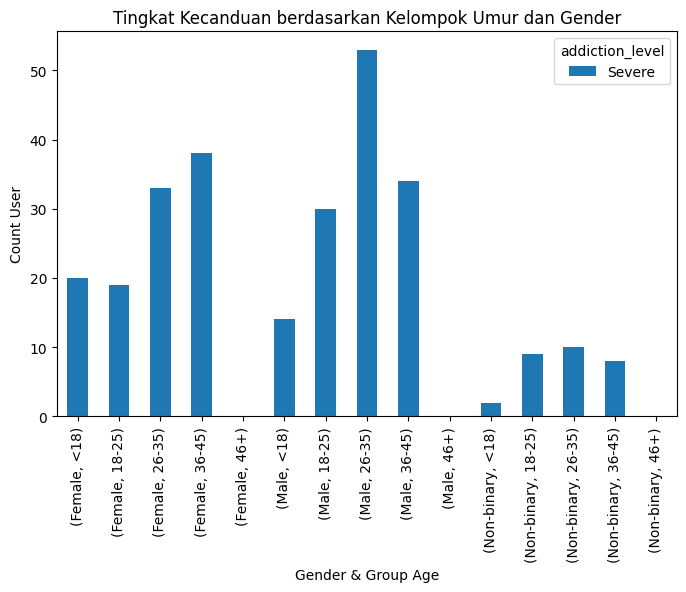

In [262]:
# Visualisasi kelompok pengguna berdasarkan gender dan age_group yang memiliki tingkat kecanduan yang tinggi
ax = data_gender_age_addiction.unstack().plot(
    kind='bar',
    figsize=(8,5),
    title='Tingkat Kecanduan berdasarkan Kelompok Umur dan Gender',
    xlabel='Gender & Group Age',
    ylabel='Count User'
)

### Insight

> Berdasarkan hasil analisa dan visualisasi data tersebut, kelompok Umur dan Gender yang memiliki Tingkat Kecanduan Tertinggi adalah Pria dengan rentang umur 26-35 dengan jumlah sebanyak 53 pengguna

References:
- [Function - pd.cut()](https://www.geeksforgeeks.org/python/pandas-cut-method-in-python/)

```
Tableau Visualization
```
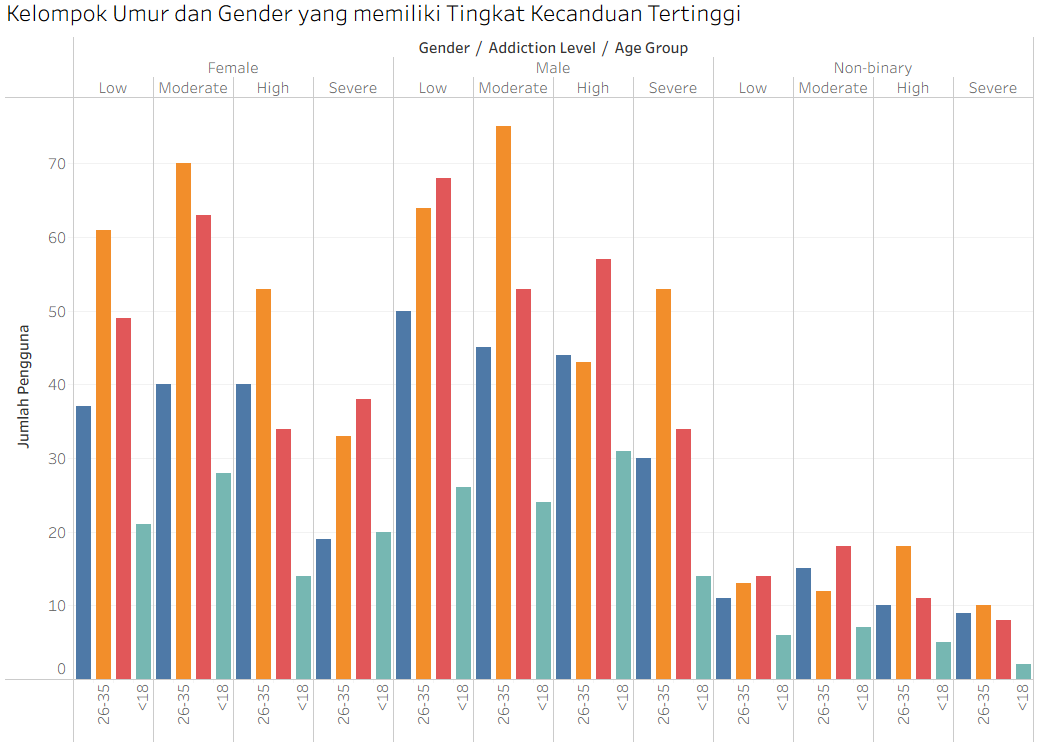

## Key Problem 2

Pada Platform Media Sosial (primary_platform) apa yang memiliki Tingkat Kecanduan (addiction_level) tertinggi?

In [263]:
# Mencari platform medsos terbanyak yang memiliki tingkat kecanduan penggunanya tinggi
most_platform = data[data['addiction_level'] == 'Severe'].groupby('primary_platform')['addiction_level'].value_counts()

most_platform.sort_values(ascending=False)

,,count
primary_platform,addiction_level,
Instagram,Severe,95
TikTok,Severe,69
YouTube,Severe,41
Snapchat,Severe,31
Twitter/X,Severe,20
Facebook,Severe,14


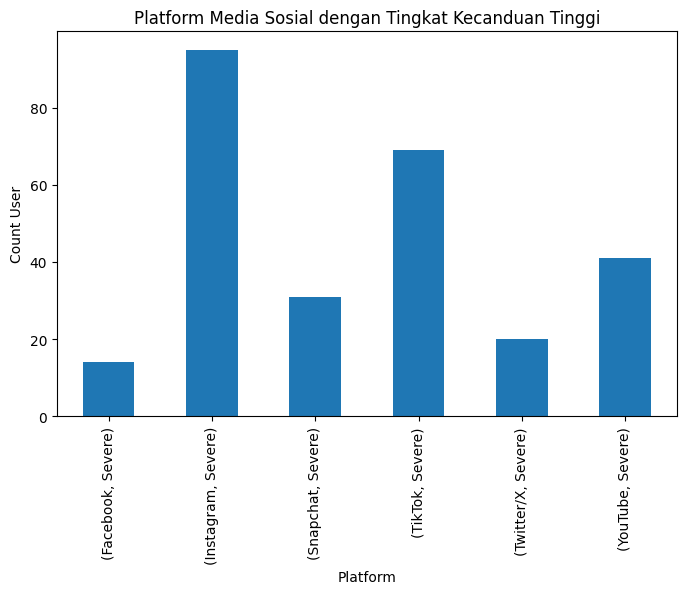

In [264]:
# Visualisasi platform medsos terbanyak yang memiliki tingkat kecanduan penggunanya parah
ax = most_platform.plot(
    kind='bar',
    figsize=(8,5),
    title='Platform Media Sosial dengan Tingkat Kecanduan Tinggi',
    xlabel='Platform',
    ylabel='Count User'
)

### Insight

> Berdasarkan hasil analisa dan visualisasi data tersebut, Platform Media Sosial yang memiliki Tingkat Kecanduan Tertinggi adalah Instagram dengan jumlah sebanyak 95 pengguna

```
Tableau Visualization
```
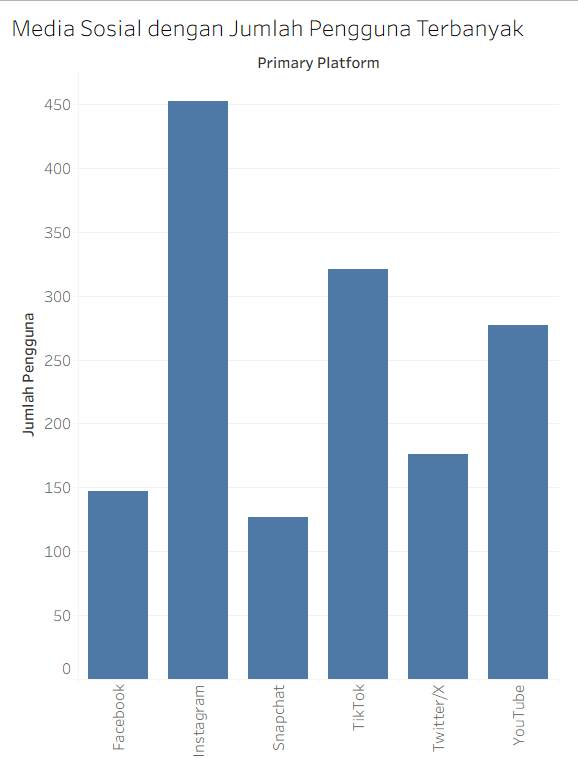

## Key Problem 3

Apakah semakin lama Durasi Penggunaan Media Sosial (daily_usage_hours) semakin tinggi juga Tingkat Kecanduannya (addiction_level)?

### Statistics Descriptive

In [265]:
# Descriptive - Measurement of Central Tendency & Dispersion-> melihat gambaran data (Mean, Median, Standart Dev, Min, Max, Quartile)
data.groupby('addiction_level')['daily_usage_hours'].describe()

,count,mean,std,min,25%,50%,75%,max
addiction_level,,,,,,,,
High,360.0,4.834167,2.065656,0.5,3.3,4.85,6.200,10.6
Low,420.0,3.830476,1.922912,0.5,2.4,3.90,5.125,8.6
Moderate,450.0,4.421333,2.078833,0.5,3.1,4.20,5.800,11.1
Severe,270.0,5.325926,1.981455,0.5,3.9,5.30,6.300,12.0


<Axes: xlabel='addiction_level', ylabel='daily_usage_hours'>

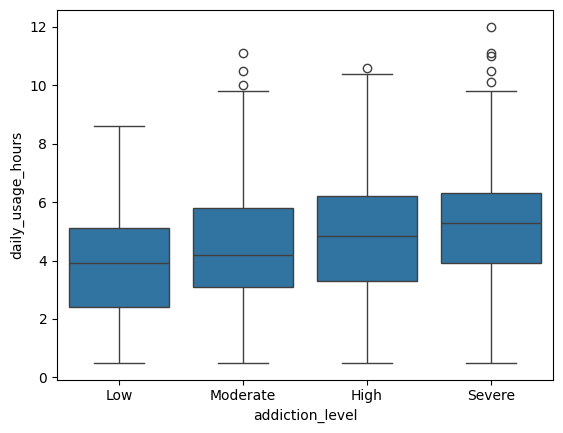

In [266]:
# Visualisasi Penyebaran Data
sns.boxplot(
    data=data,
    x='addiction_level',
    y='daily_usage_hours',
    order=['Low', 'Moderate', 'High', 'Severe']
)

Dari visualisasi sederhana ini dapat dilihat secara kasar bahwa nilai median dari Penggunaan Harian Media Sosial pada setiap Tingkat Kecanduan mengalami peningkatan:
- low = 3.9 jam/hari
- moderate = 4.2 jam/hari
- high = 4.9 jam/hari
- severe = 5.3 jam/hari

Dan dapat dilihat juga terdapat beberapa outlier pada Tingkat Kecanduan Moderate, High, dan Severe yang menandakan durasi penggunaan media sosial harian mereka lebih tinggi dari rata-rata kelompoknya (Tingkat Kecanduan)

In [267]:
# Kelompokkan data Tingkat Kecanduan dengan Durasi Penggunaan Harian
low = data[data['addiction_level'] == 'Low']['daily_usage_hours']
moderate = data[data['addiction_level'] == 'Moderate']['daily_usage_hours']
high = data[data['addiction_level'] == 'High']['daily_usage_hours']
severe = data[data['addiction_level'] == 'Severe']['daily_usage_hours']

# Descriptive - Uji Normalitas Data (Metode D'Agostino's K^2 Test)
res_low = stats.normaltest(low)
res_moderate = stats.normaltest(moderate)
res_high = stats.normaltest(high)
res_severe = stats.normaltest(severe)
res_daily_usage_hours = stats.normaltest(data['daily_usage_hours'])

print('Low - p-value:', res_low.pvalue)
print('Moderate - p-value:', res_moderate.pvalue)
print('High - p-value:', res_high.pvalue)
print('Severe - p-value:', res_severe.pvalue)
print('')
print('daily_usage_hours - p-value:', res_daily_usage_hours.pvalue)

Low - p-value: 3.7915019016179106e-05
Moderate - p-value: 0.0366494903220067
High - p-value: 0.1174759463838134
Severe - p-value: 0.018629053053273698

daily_usage_hours - p-value: 0.0011993386258381269


Dari empat Tingkat Kecanduan, hanya Tingkat Kecanduan High yang distribusinya Normal yang lainnya Distribusinya Tidak Normal, termasuk juga dengan nilai distribusi milik Durasi Penggunaan Harian Media Sosial karena nilai mereka kurang dari Alpha (0.05).

Selanjutnya, untuk uji Korelasi yang akan dipilih adalah Spearman (ρ/rho), alasannya karena mayoritas nilai distribusi dari kolom Tingkat Kecanduan tidak normal dan kolom Durasi Penggunaan Harian bersifat tidak normal, lalu untuk data Tingkat Kecanduan sudah dikonversi menjadi Rank (addiction_level_tier) dan otomatis menjadi data ordinal, sehingga penggunaan Spearman (ρ/rho) dirasa sudah tepat.

In [268]:
# Descriptive - Correlation Analysis
corr_rho, pval_s = stats.spearmanr(data['addiction_level_tier'], data['daily_usage_hours'])

print(f"rho-correlation: {corr_rho:.2f}, p-value: {pval_s}")

rho-correlation: 0.24, p-value: 2.6221363199532083e-21


### Insight

Berdasarkan nilai dari P-Value Spearman (2.622 X 10^-21/0.000000000000000000002622
) < dari Alpha (0.05), yang artinya keduanya memiliki hubungan positif yang signifikan antara Durasi Penggunaan Harian Media Sosial dengan Tingkat Kecanduan, dan berdasarkan nilai korelasi Spearman hasilnya bersifat Positive Weak, yang artinya kekuatannya hubungannya lemah.

> Dapat disimpulkan bahwa semakin Tinggi Durasi Pemakasian Harian Media Sosial semakin tinggi juga Tingkat Kecanduannya.

## Key Problem 4

Apakah Anxiety (anxiety_score) dan Depresi (depression_score) berhubungan dengan Skor Kesejahteraan Mental (mental_wellbeing_score)?

### Statistics Descriptive

In [269]:
# Descriptive - Uji Normalitas Data (Metode D'Agostino's K^2 Test)
res_anx = stats.normaltest(data['anxiety_score'])
res_dep = stats.normaltest(data['depression_score'])
res_wel = stats.normaltest(data['mental_wellbeing_score'])

print('anxiety_score, p-value:', res_anx.pvalue)
print('depression_score, p-value:', res_dep.pvalue)
print('mental_wellbeing_score, p-value:', res_wel.pvalue)

anxiety_score, p-value: 0.01613879661440462
depression_score, p-value: 0.014321326331576002
mental_wellbeing_score, p-value: 0.04541544423875013


Dikarenakan nilai P-Value dari ketiga kolom diatas < Alpha (0.05), dapat diartikan bahwa ketiga kolom diatas berdistribusi tidak normal, sehingga untuk pengujian korelasi dibawah akan menggunakan Spearman.

In [270]:
# Descriptive - Correlation Analysis
corr_rho_anx_wel, pval_s_anx_wel = stats.spearmanr(data['anxiety_score'], data['mental_wellbeing_score'])
corr_rho_dep_wel, pval_s_dep_wel = stats.spearmanr(data['depression_score'], data['mental_wellbeing_score'])

print(f"rho-correlation anxiety_score & mental_wellbeing_score: {corr_rho_anx_wel:.2f}, p-value: {pval_s_anx_wel}")
print(f"rho-correlation depression_score & mental_wellbeing_score: {corr_rho_dep_wel:.2f}, p-value: {pval_s_dep_wel}")

rho-correlation anxiety_score & mental_wellbeing_score: -0.15, p-value: 3.80517164287925e-09
rho-correlation depression_score & mental_wellbeing_score: 0.02, p-value: 0.4968005592552691


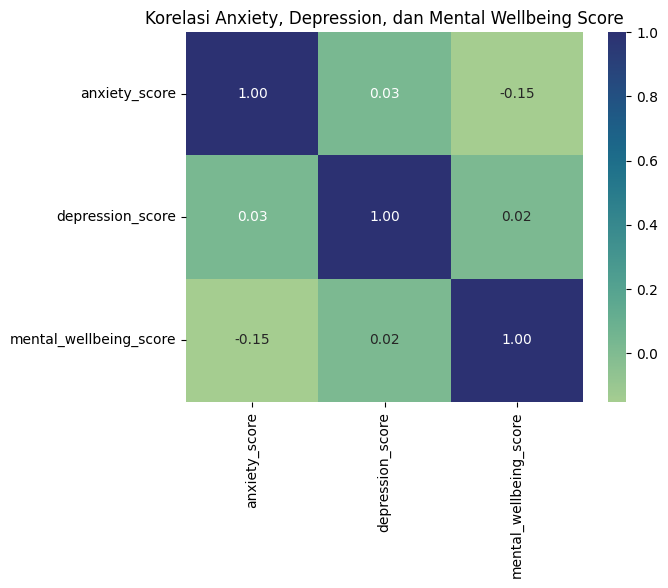

In [271]:
# Visualisasi
corr_anx_dep_well = data[['anxiety_score', 'depression_score', 'mental_wellbeing_score']].corr(method='spearman')

sns.heatmap(corr_anx_dep_well, annot=True, cmap='crest', fmt='.2f')
plt.title('Korelasi Anxiety, Depression, dan Mental Wellbeing Score')
plt.show()

### Insight

Dari hasil pengujian dan visualisasi grafik heatmap, hubungan antar variabel diatas menghasilkan:
- anxiety_score vs mental_wellbeing_score, memiliki nilai korelasi -0.15 -> Taraf Korelasi Negligible Negative
- depression_score vs mental_wellbeing_score, memiliki nilai korelasi 0.02 -> Taraf Korelasi Negligible Positive
- nilai P-Value (0.000000003805) milik anxiety_score vs mental_wellbeing_score < Alpha (0.05), yang artinya adanya hubungan yang signifikan antara Skor Kecemasan dengan Kesejahteraan Mental
- nilai P-Value (0.49) milik depresion_score vs mental_wellbeing_score > Alpha (0.05), yang artinya tidak ada hubungan yang signifikan antara Skor Depresi dengan Kesejahteraan Mental

> Dapat disimpulkan bahwa kekuatan hubungan antara Kecemasan dan Depresi dengan Kesejahteraan Mental sangat kecil dan mendekati tidak ada. Hubungan antara Kecemasan dengan Kesejahteraan Mental berjalan ke arah Negative yang artinya semakin Cemas, semakin rendah juga Kesejahteraan Mentalnya tapi kekuatannya terlalu lemah sehingga tidak teralalu berpengaruh. Namun, untuk hubungan antara Depresi dengan Kesejahteraan Mental tidak memiliki bukti kuat (hasil analisa) untuk menunjukkan adanya hubungan diantara keduanya.

References:
- [Visualization - Heatmap](https://seaborn.pydata.org/generated/seaborn.heatmap.html)

## Key Problem 5

Apakah secara general Durasi Tidur (sleep_hours) berhubungan dengan Skor Kesejahteraan Mental (mental_wellbeing_score)?

In [272]:
# Descriptive - Measurement of Central Tendency & Dispersion-> melihat gambaran data (Mean, Median, Standart Dev, Min, Max, Quartile)
data.groupby('sleep_hours_group')['mental_wellbeing_score'].describe()

/tmp/ipykernel_901/3135490495.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby('sleep_hours_group')['mental_wellbeing_score'].describe()


,count,mean,std,min,25%,50%,75%,max
sleep_hours_group,,,,,,,,
<6 jam,512.0,6.448437,1.259313,2.5,5.6,6.4,7.3,9.5
6-8 jam,724.0,6.447376,1.322842,1.5,5.5,6.5,7.4,10.0
>8 jam,202.0,6.373267,1.317346,2.7,5.5,6.5,7.2,10.0


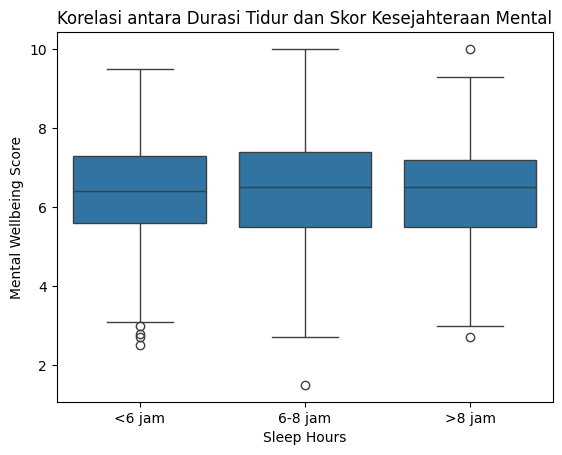

In [273]:
# Visualisasi 1 - Penyebaran Data
sns.boxplot(
    data=data,
    x='sleep_hours_group',
    y='mental_wellbeing_score'
)

plt.xlabel('Sleep Hours')
plt.ylabel('Mental Wellbeing Score')
plt.title('Korelasi antara Durasi Tidur dan Skor Kesejahteraan Mental')
plt.show()

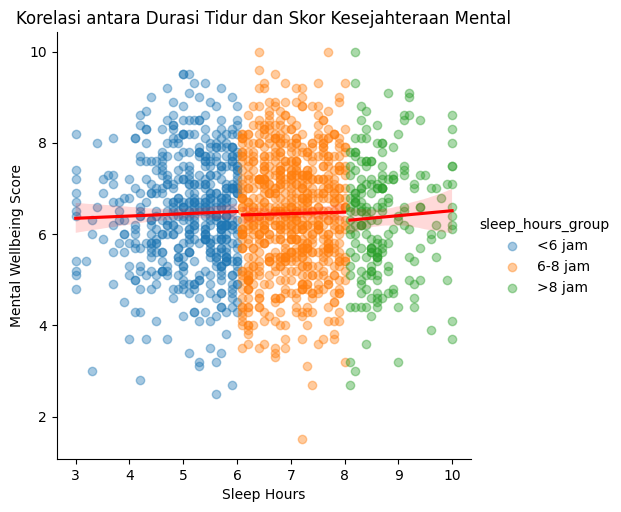

In [274]:
# Visualisasi 2 - Melihat Pola Hubungan
sns.lmplot(
    data=data,
    x='sleep_hours',
    y='mental_wellbeing_score',
    hue='sleep_hours_group',
    scatter_kws={'alpha': 0.4},
    line_kws={'color': 'red'}
    )

plt.xlabel('Sleep Hours')
plt.ylabel('Mental Wellbeing Score')
plt.title('Korelasi antara Durasi Tidur dan Skor Kesejahteraan Mental')
plt.show()

Berdasarkan tabel dan Boxplot diatas, rata-rata dan median Mental_Wellbeing_Score pada ketiga kelompok durasi tidur (<6 jam, 6-8 jam, >8 jam) hampir sama dengan nilai sekitar 6.4, secara visual juga tidak terlihat perbedaan yang besar antara tiga Kelompok Durasi Tidur dengan Kesejahteraan Mental, meskipun terdapat beberapa outlier pada setiap Kelompok Durasi Tidur.

Lalu dari grafik lmplot juga menunjukkan persebaran pada masing-masing kelompok terlihat cukup luas dan garis regresi cenderung datar, sehingga tidak terlihat adanya hubungan yang jelas antara Durasi Tidur dan Kesejahteraan Mental.

### Insight
> Dari analisa sederhana visualisasi diatas, secara visual masing-masing Kelompok Durasi Tidur memiliki tingkat Kesejahteraan Mental yang relatif sama, dan tidak terlihat hubungan linear yang kuat antara Durasi Tidur dengan Kesejahteraan Mental.

References:
- [Function - pd.cut()](https://www.geeksforgeeks.org/python/pandas-cut-method-in-python/)
- [Visualization - lmplot](https://seaborn.pydata.org/generated/seaborn.lmplot.html)

```
Tableau Visualization - Penyebaran Data
```
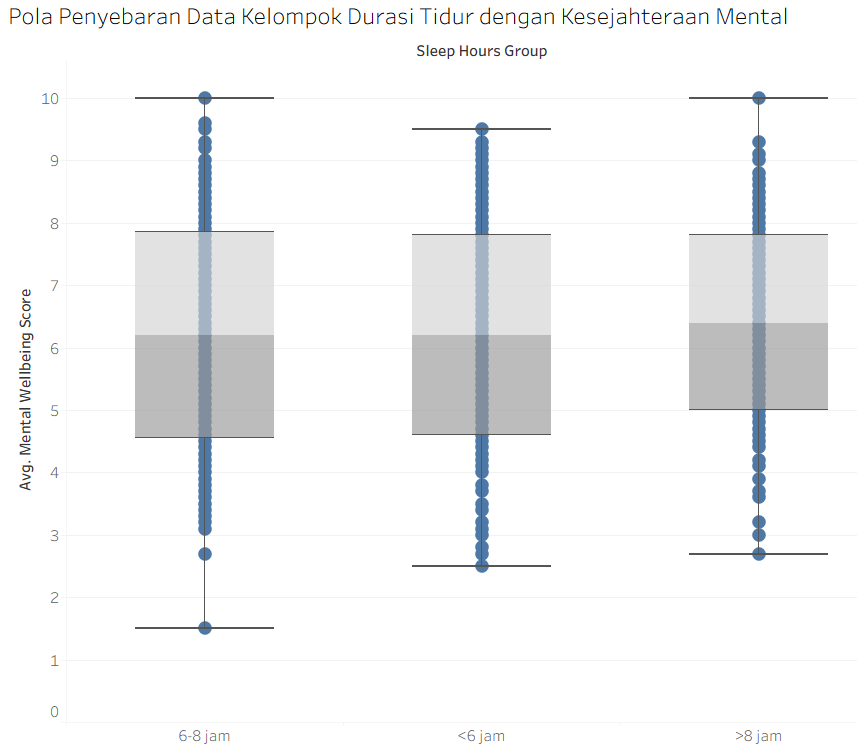

## Key Problem 6

Apakah orang yang Kesepian (loneliness_score) memiliki Skor Kesejahteraan Mental (mental_wellbeing_score) yang kecil?

In [275]:
# Buat kelompok skor kesepian menjadi 4 bagian
data['loneliness_group'] = pd.cut(
    data['loneliness_score'],
    bins=[0, 2.5, 5, 7.5, 10],
    labels=['Tidak Kesepian', 'Kesepian Ringan', 'Kesepian Sedang', 'Sangat Kesepian']
)

# Descriptive - Measurement of Central Tendency & Dispersion-> melihat gambaran data (Mean, Median, Standart Dev, Min, Max, Quartile)
data.groupby('loneliness_group')['mental_wellbeing_score'].describe()

/tmp/ipykernel_901/625113038.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby('loneliness_group')['mental_wellbeing_score'].describe()


,count,mean,std,min,25%,50%,75%,max
loneliness_group,,,,,,,,
Tidak Kesepian,238.0,6.566387,1.262058,3.0,5.6,6.6,7.400,10.0
Kesepian Ringan,668.0,6.505090,1.321862,1.5,5.6,6.6,7.400,10.0
Kesepian Sedang,494.0,6.306883,1.273013,3.2,5.4,6.2,7.200,10.0
Sangat Kesepian,82.0,6.013415,1.237257,3.1,5.3,6.1,6.775,8.9


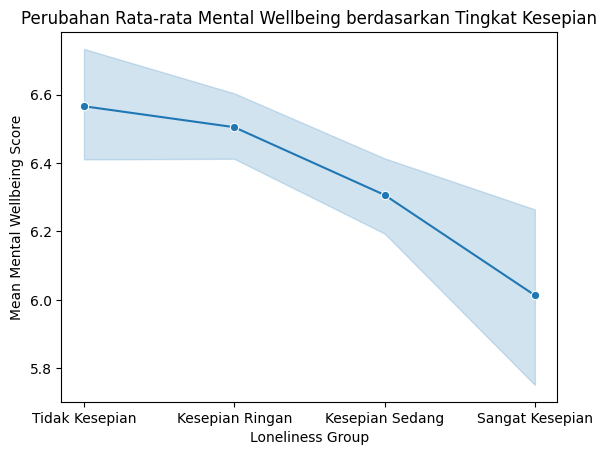

In [276]:
# Visualisasi
sns.lineplot(
    data=data,
    x='loneliness_group',
    y='mental_wellbeing_score',
    estimator='mean',
    marker='o'
)

plt.xlabel('Loneliness Group')
plt.ylabel('Mean Mental Wellbeing Score')
plt.title('Perubahan Rata-rata Mental Wellbeing berdasarkan Tingkat Kesepian')

plt.show()

Berdasarkan tabel dan lineplot diatas, nilai rata-rata Skor Kesehatan mental terhadap pada empat kelompok tingkat kesepian (Tidak Kesepian, Kesepian Ringan, Kesepian Sedang, Sangat Kesepian) mengalami penuruan seiring tingginya Tingkat Kesepian, dari grafil lineplot juga terlihat jelas bahwa semakin tinggi Tingkat Kesepiannya maka semakin rendah rata-rata Skor Kesehatan Mentalnya.

### Insight

> Dari analisa sederhana diatas, menunjukkan bahwa orang yang memiliki Tingkat Kesepian yang tinggi maka Skor Kesejahteraan Mentalnya kecil, dan begitu juga sebaliknya Orang yang memiliki Tingkat Kesepian yang rendah maka lebih Sejahtera Mentalnya.

References:
- [Visualization - Lineplot](https://seaborn.pydata.org/generated/seaborn.lineplot.html)

```
Tableau Visualization
```
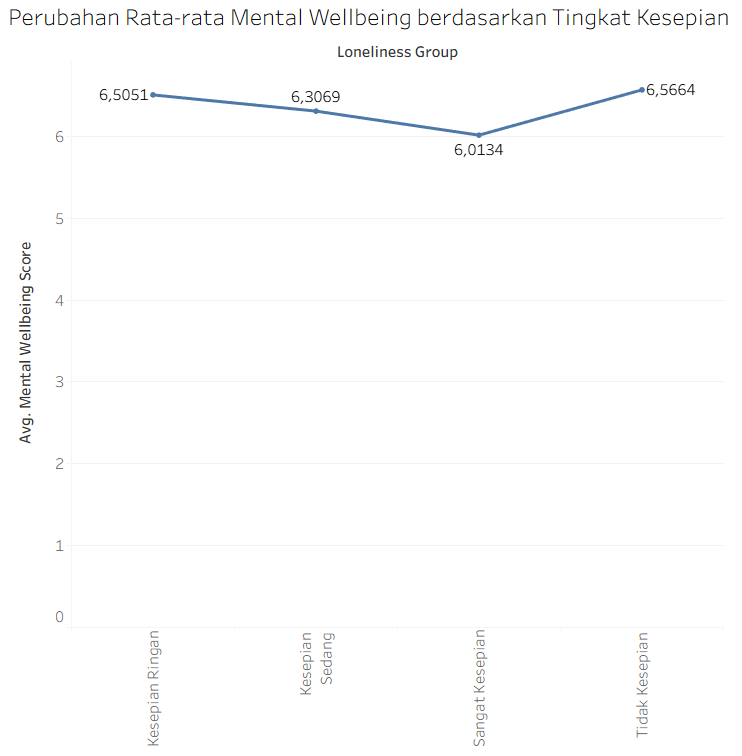

## Key Problem 7

Bagaimana hubungan antara Addiction_Level itu sendiri dengan Mental_Wellbeing_Score?

### Statistics Descriptive

In [277]:
# Descriptive - Measurement of Central Tendency & Dispersion-> melihat gambaran data (Mean, Median, Standart Dev, Min, Max, Quartile)
data.groupby('addiction_level')['mental_wellbeing_score'].describe()

,count,mean,std,min,25%,50%,75%,max
addiction_level,,,,,,,,
High,360.0,5.770278,0.471092,4.5,5.500,5.8,6.1,7.2
Low,420.0,7.904524,0.666916,6.2,7.400,7.9,8.3,10.0
Moderate,450.0,6.682667,0.511003,4.9,6.300,6.7,7.0,8.3
Severe,270.0,4.593333,0.715905,1.5,4.225,4.7,5.1,6.2


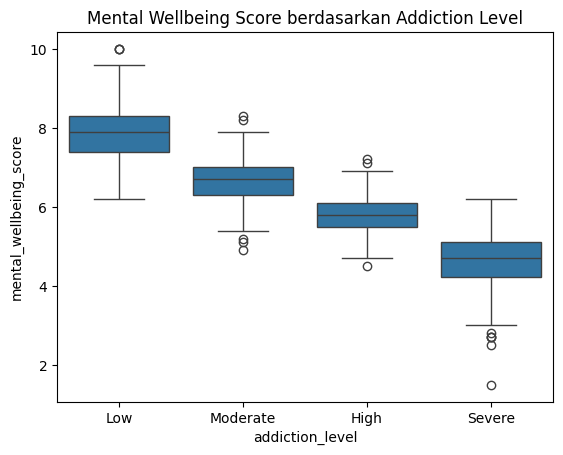

In [278]:
# Visualisasi
sns.boxplot(
    data=data,
    x='addiction_level',
    y='mental_wellbeing_score',
    order=['Low','Moderate','High','Severe']
    )

plt.title('Mental Wellbeing Score berdasarkan Addiction Level')
plt.show()

Dari tabel dan boxplot di atas, terlihat bahwa rata-rata Mental_Wellbeing_Score semakin menurun seiring naiknya tingkat kecanduan. Pengguna dengan Tingkat Kecanduan "Low" punya rata-rata wellbeing paling tinggi (7.90), lalu semakin turun di Tingkat Kecanduan "Moderate" (6.68), Tingkat Kecanduan "High" (5.77), dan paling rendah ada di Tingkat Kecanduan "Severe" (4.59). Dari grafik Boxplot juga terlihat secara visual kalau posisi kotak semakin turun dari Low ke Severe.

In [279]:
# Kelompokkan data Tingkat Kecanduan dengan mental_wellbeing_score
low_ad_well = data[data['addiction_level']=='Low']['mental_wellbeing_score']
moderate_ad_well = data[data['addiction_level']=='Moderate']['mental_wellbeing_score']
high_ad_well = data[data['addiction_level']=='High']['mental_wellbeing_score']
severe_ad_well = data[data['addiction_level']=='Severe']['mental_wellbeing_score']

# Descriptive - Uji Normalitas Data (Metode D'Agostino's K^2 Test)
res_low_ad_well = stats.normaltest(low_ad_well)
res_moderat_ad_well = stats.normaltest(moderate_ad_well)
res_high_ad_well = stats.normaltest(high_ad_well)
res_severe_ad_well = stats.normaltest(severe_ad_well)

print('Low - p-value:', res_low_ad_well.pvalue)
print('Moderate - p-value:', res_moderat_ad_well.pvalue)
print('High - p-value:', res_high_ad_well.pvalue)
print('Severe - p-value:', res_severe_ad_well.pvalue)

Low - p-value: 0.0020567659105460577
Moderate - p-value: 0.605863265069086
High - p-value: 0.4439317216002877
Severe - p-value: 4.6412116972185213e-07


Berdasarkan hasil P-Value diatas, 2 dari 4 Tingkat Kecanduan memiliki Distribusi yang Normal (Moderate, High) karena P-Valuenya > Alpha (0.05), dan 2 sisanya (Low, Severe) memiliki Distribusi yang Tidak Normal karena P-Valuenya < Alpha (0.05).

Karena Hasil uji Distribusi diatas, langkah selanjutnya untuk Uji Statistik Inferensial tidak bisa menggunakan ANOVA, dikarenakan 2 dari 4 Tingkat Kecanduan memiliki Distribusi yang Tidak Normal. Oleh karena itu, untuk Uji Statistik Inferensialnya akan menggunakan Kruskal-Wallis sebagai pengganti ANOVA.

### Statistics Inferential

In [280]:
# Inferential - Kruskal-Wallis
res_kw = stats.kruskal(low_ad_well, moderate_ad_well, high_ad_well, severe_ad_well)

print(f'P-value: {res_kw.pvalue:.4f}')

P-value: 0.0000


Berdasarkan hasil uji Kruskal-Wallis, nilai P-Value yang didapatkan < Alpha (0,05), yang artinya terdapat perbedaan yang signifikan antara Mental_Wellbeing_Score terhadap pengguna dengan Primary_Platform yang berbeda.

### Insight

> Berdasarkan semua hasil pengujian sebelumnya, dapat disimpulkan bahwa semakin tinggi Tingkat Kecanduan Media Sosial, semakin rendah juga Kesejahteraan Mentalnya.

```
Tableau Visualization
```
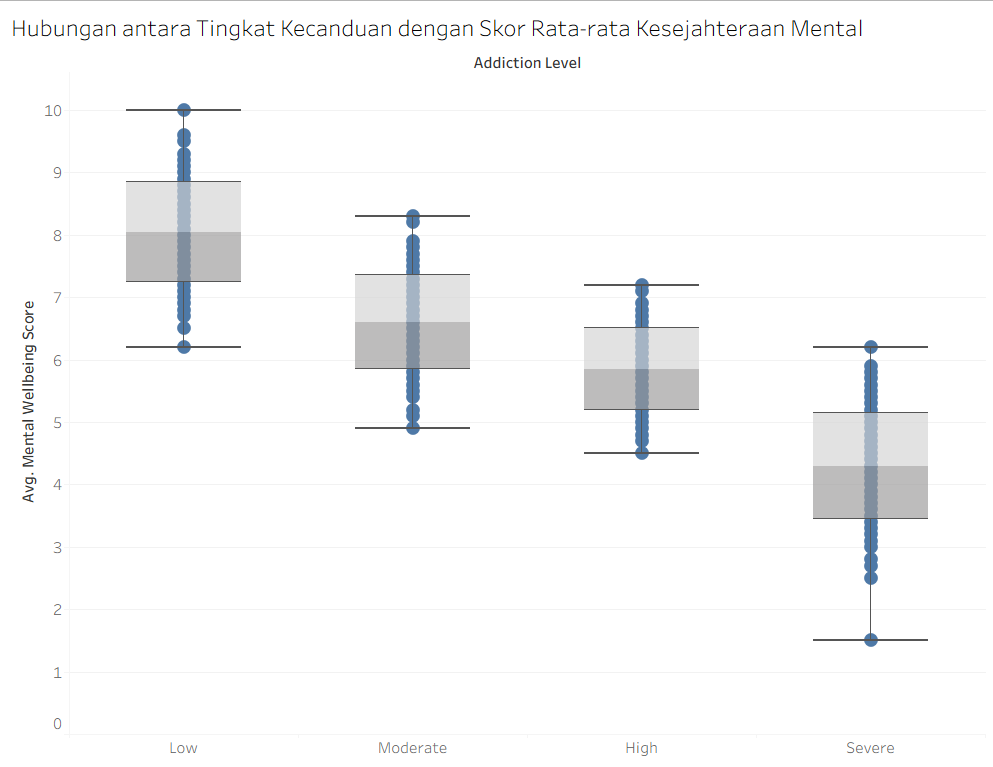

# Export Data Clean untuk Visualisasi Tableau

In [281]:
# Export Clean Data to .csv file
data.to_csv('social_media_addiction_mental_wellbeing_clean.csv', index=False)

# Kesimpulan

Berdasarkan hasil analisis terhadap lebih dari 1.000 pengguna media sosial, dapat disimpulkan hal-hal berikut untuk menjawab Problem Statement penelitian ini:

1. Profil Pengguna dengan Tingkat Kecanduan Tinggi
- Pengguna dengan Tingkat kecanduan (Addiction_Level) "Severe" paling banyak ditemukan pada kelompok Pria usia 26-35 tahun, dan platform Instagram menjadi platform dengan jumlah pengguna kecanduan berat terbanyak.

2. Perilaku Penggunaan Media Sosial (Platform Behavior) berhubungan dengan Tingkat Kecanduan
- Durasi penggunaan harian (Daily_Usage_Hours) terbukti memiliki hubungan positif secara signifikan dengan Tingkat Kecanduan (Addiction_Level) (rho = 0.24, p-value < 0.05), meski kekuatan hubungannya tergolong lemah. Artinya semakin lama durasi pemakaian, semakin tinggi juga tingkat kecanduannya.

3. Indikator Kesehatan Mental sebagian berhubungan dengan Kesejahteraan Mental
- Anxiety_Score memiliki hubungan negatif yang signifikan dengan Mental_Wellbeing_Score (rho = -0.15, p-value < 0.05), meski kekuatannya sangat lemah (negligible).
- Depresi (Depression_Score) tidak menunjukkan hubungan yang signifikan dengan Kesejahteraan Mental (Mental_Wellbeing_Score) (p-value = 0.497).
- Durasi tidur (Sleep_Hours) tidak menunjukkan adanya pola hubungan yang jelas terhadap Kesejahteraan Mental (Mental_Wellbeing_Score).
- Tingkat kesepian (Loneliness_Score) menunjukkan pola yang jelas: semakin tinggi kesepian, semakin rendah Kesejahteraan Mentalnya (Mental_Wellbeing_Score).

4. Tingkat Kecanduan dan Kesejahteraan Mental Saling Berkaitan Erat
- Ditemukan pola yang sangat konsisten dan signifikan secara statistik (Kruskal-Wallis, p-value < 0.05): semakin tinggi Addiction_Level (dari Low ke Severe), semakin rendah Mental_Wellbeing_Score penggunanya (rata-rata turun dari 7.90 -> Tingkat Low menjadi 4.59 -> Tingkat Severe).

Kesimpulan Utama dan Actionable Recomendation:
> Perilaku penggunaan media sosial (khususnya durasi pemakaian) dan beberapa indikator kesehatan mental (terutama kecemasan dan kesepian) terbukti berhubungan dengan Tingkat Kecanduan Media Sosial. Yang paling penting, Tingkat Kecanduan itu sendiri terbukti memiliki hubungan yang kuat dan signifikan dengan Kesejahteraan Mental penggunanya, dari kesimpulan tersebut penting bahwa setiap pengguna perlu membatasi Durasi Penggunaan Media Sosial dan mewaspadai Kecanduan, hal ini dapat menjadi langkah penting setiap Pengguna Media Sosial dalam menjaga Kesejahteraan Mentalnya.